<a href="https://colab.research.google.com/github/checkcode01/60-Days-Challenge/blob/main/Day13_HR_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Day 13 is one of the BIGGEST breakthroughs in understanding modern AI.
Until now:
TF-IDF matched keywords
Term Frequency (TF):
Measures how often a word appears in a document.
Example: If “AI” appears 10 times in an article, it gets a higher TF score.
Inverse Document Frequency (IDF):
Reduces importance of very common words across many documents like “the”, “is”, “good”.
Rare but meaningful words get higher importance.

AI looked for overlapping words
Today: 👉 AI learns MEANING.
This is the foundation behind:
ChatGPT memory
semantic search
recommendation systems
LinkedIn job matching
AI assistants
HR talent intelligence systems

In [ ]:
!pip install openai scikit-learn matplotlib

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sentence_transformers import SentenceTransformer

from openai import OpenAI

In [ ]:
from sentence_transformers import SentenceTransformer

In [ ]:
model = SentenceTransformer(
      'all-MiniLM-L6-v2'
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Imagine HR groups employees by department.
Embeddings group sentences by meaning.
Example:
Sentence
Meaning
remote work
work from home
salary hike
compensation increase
Different words. Same semantic meaning

In [ ]:
sentences = [

      # Recruitment
          "The company is hiring software engineers.",
              "Interview candidates must complete technical assessments.",
                  "Recruiters are screening resumes for open positions.",
                      "The hiring team scheduled interviews next week.",
                          "Applicants submitted job applications online.",

                              # Benefits
                                  "Employees receive annual bonuses and insurance.",
                                      "The company offers medical and wellness benefits.",
                                          "Staff members are eligible for paid leave.",
                                              "Workers receive compensation and retirement plans.",
                                                  "The HR team explained healthcare coverage.",

                                                      # Learning
                                                          "Employees attended leadership training workshops.",
                                                              "The company provides online certification programs.",
                                                                  "Managers encourage skill development initiatives.",
                                                                      "Staff completed AI and analytics training.",
                                                                          "Learning platforms help employees improve skills.",

                                                                              # Remote Work
                                                                                  "Employees can work remotely during emergencies.",
                                                                                      "The company supports flexible work arrangements.",
                                                                                          "Managers monitor productivity for remote teams.",
                                                                                              "Work from home policies were updated recently.",
                                                                                                  "Virtual meetings help distributed teams collaborate."
                                                                                                  ]

In [ ]:
import time
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

start_time = time.time()

embeddings = model.encode(sentences)

end_time = time.time()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
import numpy as np

embedding_matrix = np.array(embeddings)

print(embedding_matrix.shape)

(20, 384)


In [13]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embedding_matrix)

print(similarity)

[[1.0000002  0.44604346 0.3831184  0.46756065 0.4163498  0.22880235
  0.2882819  0.184625   0.1937822  0.20949563 0.26782262 0.41505754
  0.33784068 0.35713708 0.2993437  0.16121553 0.37409705 0.2628423
  0.19702306 0.20788671]
 [0.44604346 1.0000002  0.37524983 0.4451971  0.375814   0.01910978
  0.02483965 0.09245501 0.06632351 0.1948621  0.25934398 0.26440513
  0.28979048 0.383071   0.2261998  0.0570159  0.16087042 0.16472721
  0.04714517 0.14616741]
 [0.3831184  0.37524983 0.99999994 0.37607133 0.45917654 0.17931828
  0.20054343 0.20087937 0.19257016 0.24129897 0.22426495 0.26264536
  0.23154792 0.2695709  0.22712697 0.10576797 0.24279389 0.14397025
  0.20281969 0.06851494]
 [0.46756065 0.4451971  0.37607133 1.         0.45161253 0.0709108
  0.15502012 0.18245868 0.1078558  0.28356725 0.35287845 0.14514998
  0.23419452 0.28567272 0.18040383 0.06833935 0.24481264 0.12324114
  0.22057384 0.19518855]
 [0.4163498  0.375814   0.45917654 0.45161253 1.0000001  0.07122409
  0.13962841 0.160

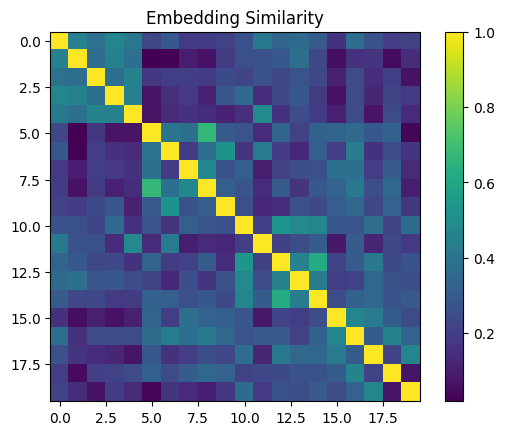

In [14]:
plt.imshow(similarity)
plt.colorbar()
plt.title("Embedding Similarity")
plt.show()